<a href="https://colab.research.google.com/github/ManasAyyalaraju/personal-finance-health-predictor/blob/main/notebooks/04_Fraud_Detection_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Personal_Finance_ML_Project')

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning - Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Standard Classification (with SMOTE)
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# Model Persistence
import joblib
import os

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Load Preprocessed Fraud Data

In [ ]:
# Define data path
data_path = 'data/processed/'

# Load training data (imbalanced)
X_train = pd.read_csv(data_path + 'fraud_X_train.csv')
y_train = pd.read_csv(data_path + 'fraud_y_train.csv').squeeze()

# Load test data (imbalanced - real-world scenario)
X_test = pd.read_csv(data_path + 'fraud_X_test.csv')
y_test = pd.read_csv(data_path + 'fraud_y_test.csv').squeeze()

# Load SMOTE balanced training data (for supervised models)
X_train_balanced = pd.read_csv(data_path + 'fraud_X_train_balanced.csv')
y_train_balanced = pd.read_csv(data_path + 'fraud_y_train_balanced.csv').squeeze()

print("✅ Data loaded successfully!")

# Display dataset info
print(f"\n📊 Dataset Shapes:")
print(f"   Training set (imbalanced): {X_train.shape}")
print(f"   Training set (SMOTE balanced): {X_train_balanced.shape}")
print(f"   Test set: {X_test.shape}")

print(f"\n📈 Target Distribution:")
print(f"\n   Original Training Set:")
print(f"      Class 0 (Normal): {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.2f}%)")
print(f"      Class 1 (Fraud): {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.2f}%)")

print(f"\n   SMOTE Balanced Training Set:")
print(f"      Class 0 (Normal): {(y_train_balanced == 0).sum():,} ({(y_train_balanced == 0).mean()*100:.2f}%)")
print(f"      Class 1 (Fraud): {(y_train_balanced == 1).sum():,} ({(y_train_balanced == 1).mean()*100:.2f}%)")

print(f"\n   Test Set (Real-world distribution):")
print(f"      Class 0 (Normal): {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.2f}%)")
print(f"      Class 1 (Fraud): {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.2f}%)")

print(f"\n🎯 Features Available: {X_train.shape[1]}")
print(f"\n📋 Sample Features:")
for i, col in enumerate(X_train.columns[:10], 1):
    print(f"   {i:2d}. {col}")
if X_train.shape[1] > 10:
    print(f"   ... and {X_train.shape[1] - 10} more features")

✅ Data loaded successfully!

📊 Dataset Shapes:
   Training set (imbalanced): (227845, 44)
   Training set (SMOTE balanced): (341176, 44)
   Test set: (56962, 44)

📈 Target Distribution:

   Original Training Set:
      Class 0 (Normal): 227,451 (99.83%)
      Class 1 (Fraud): 394 (0.17%)

   SMOTE Balanced Training Set:
      Class 0 (Normal): 227,451 (66.67%)
      Class 1 (Fraud): 113,725 (33.33%)

   Test Set (Real-world distribution):
      Class 0 (Normal): 56,864 (99.83%)
      Class 1 (Fraud): 98 (0.17%)

🎯 Features Available: 44

📋 Sample Features:
    1. Time
    2. V1
    3. V2
    4. V3
    5. V4
    6. V5
    7. V6
    8. V7
    9. V8
   10. V9
   ... and 34 more features


# Isolation Forest

In [ ]:
# This is unsupervised - we train on normal data to learn what "normal" looks like
X_train_normal = X_train[y_train == 0]

print(f"   Training on {len(X_train_normal):,} normal transactions...")

# Train model
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.002,  # Expected fraud rate (0.2%)
    random_state=42,
    n_jobs=-1,
    verbose=0
)

iso_forest.fit(X_train_normal)

# Predictions (-1 = anomaly/fraud, 1 = normal)
y_train_pred_iso = iso_forest.predict(X_train)
y_test_pred_iso = iso_forest.predict(X_test)

# Convert to binary (0 = normal, 1 = fraud)
y_train_pred_iso = (y_train_pred_iso == -1).astype(int)
y_test_pred_iso = (y_test_pred_iso == -1).astype(int)

# Get anomaly scores (more negative = more anomalous)
y_train_scores_iso = -iso_forest.score_samples(X_train)
y_test_scores_iso = -iso_forest.score_samples(X_test)

# Calculate metrics
train_acc_iso = accuracy_score(y_train, y_train_pred_iso)
test_acc_iso = accuracy_score(y_test, y_test_pred_iso)
test_precision_iso = precision_score(y_test, y_test_pred_iso, zero_division=0)
test_recall_iso = recall_score(y_test, y_test_pred_iso)
test_f1_iso = f1_score(y_test, y_test_pred_iso)

# Calculate ROC-AUC using anomaly scores
train_auc_iso = roc_auc_score(y_train, y_train_scores_iso)
test_auc_iso = roc_auc_score(y_test, y_test_scores_iso)

print("\n📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"      Accuracy: {train_acc_iso:.4f}")
print(f"      ROC-AUC: {train_auc_iso:.4f}")
print(f"\n   Test Set:")
print(f"      Accuracy: {test_acc_iso:.4f}")
print(f"      Precision: {test_precision_iso:.4f} (of flagged transactions, {test_precision_iso:.1%} are fraud)")
print(f"      Recall: {test_recall_iso:.4f} (catches {test_recall_iso:.1%} of fraud)")
print(f"      F1-Score: {test_f1_iso:.4f}")
print(f"      ROC-AUC: {test_auc_iso:.4f}")

print("\n📊 Classification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred_iso,
                          target_names=['Normal', 'Fraud'],
                          digits=4))

print("\n💡 Key Insight:")
print(f"   Isolation Forest flagged {y_test_pred_iso.sum():,} transactions as fraud")
print(f"   Of these, {(y_test[y_test_pred_iso == 1] == 1).sum():,} were actual fraud")
print(f"   Missed {(y_test == 1).sum() - (y_test[y_test_pred_iso == 1] == 1).sum():,} fraud cases")

   Training on 227,451 normal transactions...

📈 Performance Metrics:

   Training Set:
      Accuracy: 0.9966
      ROC-AUC: 0.9354

   Test Set:
      Accuracy: 0.9966
      Precision: 0.1597 (of flagged transactions, 16.0% are fraud)
      Recall: 0.2347 (catches 23.5% of fraud)
      F1-Score: 0.1901
      ROC-AUC: 0.9353

📊 Classification Report (Test Set):

              precision    recall  f1-score   support

      Normal     0.9987    0.9979    0.9983     56864
       Fraud     0.1597    0.2347    0.1901        98

    accuracy                         0.9966     56962
   macro avg     0.5792    0.6163    0.5942     56962
weighted avg     0.9972    0.9966    0.9969     56962


💡 Key Insight:
   Isolation Forest flagged 144 transactions as fraud
   Of these, 23 were actual fraud
   Missed 75 fraud cases


# XGBoost with SMOTE

In [ ]:
# Calculate scale_pos_weight for the imbalanced test scenario
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost on SMOTE-balanced data
xgb_fraud = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # Already balanced by SMOTE
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

print(f"   Training on {len(X_train_balanced):,} balanced samples...")
xgb_fraud.fit(X_train_balanced, y_train_balanced)

# Predictions
y_train_pred_xgb = xgb_fraud.predict(X_train)
y_test_pred_xgb = xgb_fraud.predict(X_test)
y_train_proba_xgb = xgb_fraud.predict_proba(X_train)[:, 1]
y_test_proba_xgb = xgb_fraud.predict_proba(X_test)[:, 1]

# Calculate metrics
train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
test_precision_xgb = precision_score(y_test, y_test_pred_xgb, zero_division=0)
test_recall_xgb = recall_score(y_test, y_test_pred_xgb)
test_f1_xgb = f1_score(y_test, y_test_pred_xgb)
train_auc_xgb = roc_auc_score(y_train, y_train_proba_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)

print("\n📈 Performance Metrics:")
print(f"\n   Training Set:")
print(f"      Accuracy: {train_acc_xgb:.4f}")
print(f"      ROC-AUC: {train_auc_xgb:.4f}")
print(f"\n   Test Set:")
print(f"      Accuracy: {test_acc_xgb:.4f}")
print(f"      Precision: {test_precision_xgb:.4f} (of flagged transactions, {test_precision_xgb:.1%} are fraud)")
print(f"      Recall: {test_recall_xgb:.4f} (catches {test_recall_xgb:.1%} of fraud)")
print(f"      F1-Score: {test_f1_xgb:.4f}")
print(f"      ROC-AUC: {test_auc_xgb:.4f}")

print("\n📊 Classification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred_xgb,
                          target_names=['Normal', 'Fraud'],
                          digits=4))

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_fraud.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔝 Top 10 Most Important Features for Fraud Detection:")
for i, row in feature_importance_xgb.head(10).iterrows():
    print(f"   {row['Feature']:<30} {row['Importance']:>8.4f}")

print("\n💡 Key Insight:")
print(f"   XGBoost flagged {y_test_pred_xgb.sum():,} transactions as fraud")
print(f"   Of these, {(y_test[y_test_pred_xgb == 1] == 1).sum():,} were actual fraud")
print(f"   Missed {(y_test == 1).sum() - (y_test[y_test_pred_xgb == 1] == 1).sum():,} fraud cases")

   Training on 341,176 balanced samples...

📈 Performance Metrics:

   Training Set:
      Accuracy: 0.9991
      ROC-AUC: 0.9999

   Test Set:
      Accuracy: 0.9984
      Precision: 0.5250 (of flagged transactions, 52.5% are fraud)
      Recall: 0.8571 (catches 85.7% of fraud)
      F1-Score: 0.6512
      ROC-AUC: 0.9774

📊 Classification Report (Test Set):

              precision    recall  f1-score   support

      Normal     0.9998    0.9987    0.9992     56864
       Fraud     0.5250    0.8571    0.6512        98

    accuracy                         0.9984     56962
   macro avg     0.7624    0.9279    0.8252     56962
weighted avg     0.9989    0.9984    0.9986     56962


🔝 Top 10 Most Important Features for Fraud Detection:
   V14                              0.3391
   V10                              0.1608
   high_amount                      0.0594
   V12                              0.0469
   V4                               0.0364
   V8                               0.02

# Model Comparison


📊 Model Performance Summary:

           Model  Train Accuracy  Test Accuracy  Train ROC-AUC  Test ROC-AUC  Test Precision  Test Recall  Test F1-Score
Isolation Forest        0.996621       0.996559       0.935361      0.935284        0.159722     0.234694       0.190083
 XGBoost + SMOTE        0.999140       0.998420       0.999939      0.977425        0.525000     0.857143       0.651163

🏆 Best Model: XGBoost + SMOTE
   Test ROC-AUC: 0.9774
   Test Recall: 0.8571
   Test Precision: 0.5250


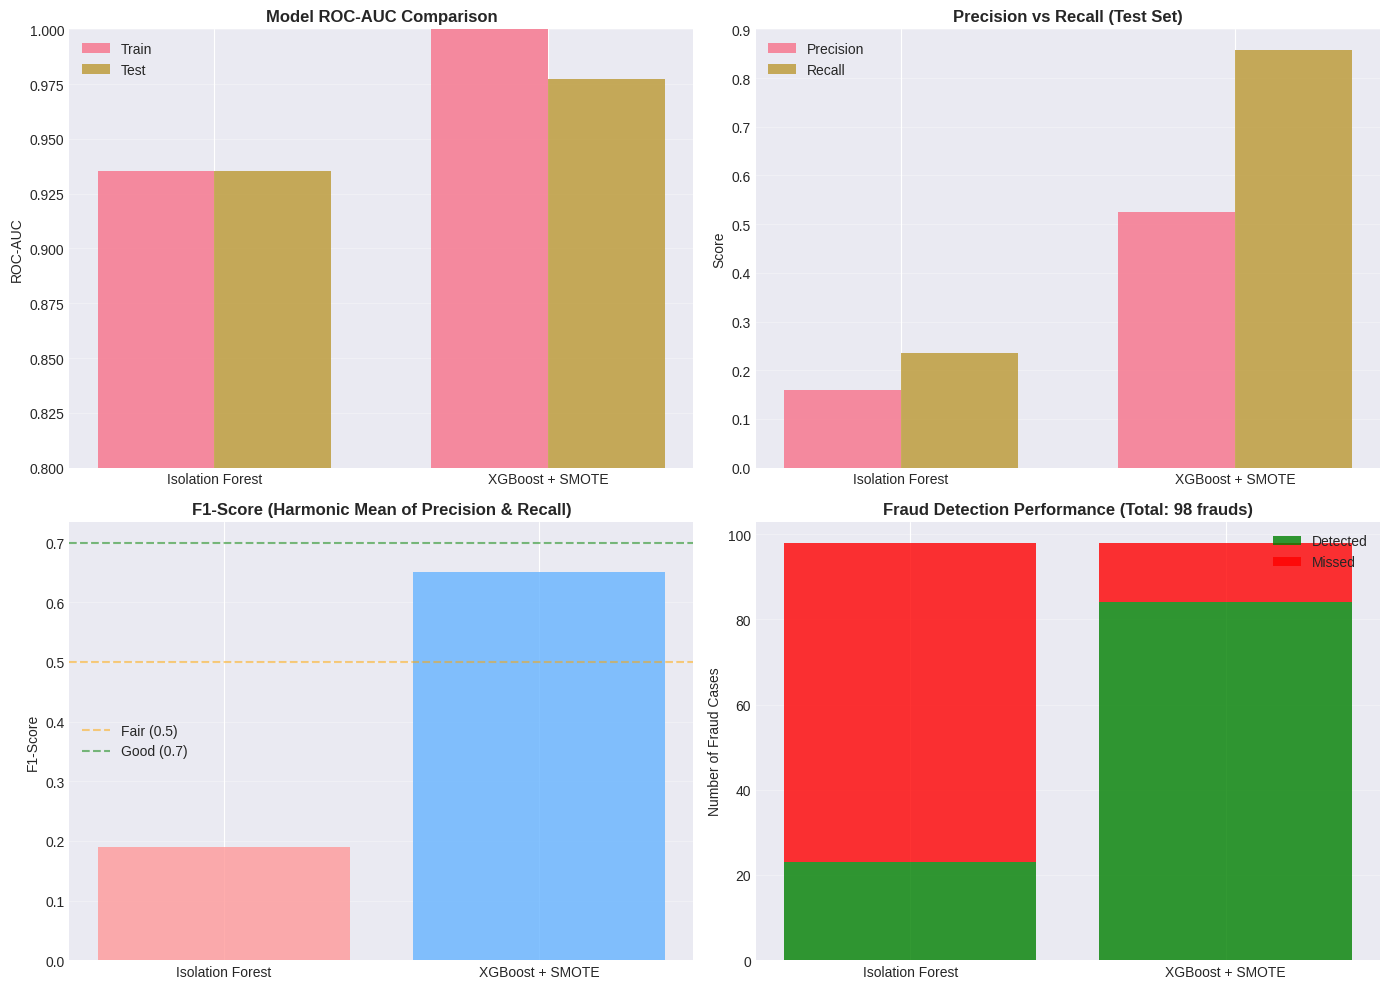

In [ ]:
# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'XGBoost + SMOTE'],
    'Train Accuracy': [train_acc_iso, train_acc_xgb],
    'Test Accuracy': [test_acc_iso, test_acc_xgb],
    'Train ROC-AUC': [train_auc_iso, train_auc_xgb],
    'Test ROC-AUC': [test_auc_iso, test_auc_xgb],
    'Test Precision': [test_precision_iso, test_precision_xgb],
    'Test Recall': [test_recall_iso, test_recall_xgb],
    'Test F1-Score': [test_f1_iso, test_f1_xgb]
})

print("\n📊 Model Performance Summary:\n")
print(model_comparison.to_string(index=False))

# Find best model
best_model_idx = model_comparison['Test ROC-AUC'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_model_auc = model_comparison.loc[best_model_idx, 'Test ROC-AUC']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test ROC-AUC: {best_model_auc:.4f}")
print(f"   Test Recall: {model_comparison.loc[best_model_idx, 'Test Recall']:.4f}")
print(f"   Test Precision: {model_comparison.loc[best_model_idx, 'Test Precision']:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: ROC-AUC Comparison
ax = axes[0, 0]
x = np.arange(len(model_comparison))
width = 0.35
ax.bar(x - width/2, model_comparison['Train ROC-AUC'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, model_comparison['Test ROC-AUC'], width, label='Test', alpha=0.8)
ax.set_ylabel('ROC-AUC')
ax.set_title('Model ROC-AUC Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['Model'], rotation=0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.8, 1.0])

# Plot 2: Precision vs Recall Trade-off
ax = axes[0, 1]
width = 0.35
ax.bar(x - width/2, model_comparison['Test Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + width/2, model_comparison['Test Recall'], width, label='Recall', alpha=0.8)
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall (Test Set)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['Model'], rotation=0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: F1-Score Comparison
ax = axes[1, 0]
colors = ['#ff9999' if x < 0.5 else '#66b3ff' if x < 0.7 else '#99ff99'
          for x in model_comparison['Test F1-Score']]
ax.bar(x, model_comparison['Test F1-Score'], color=colors, alpha=0.8)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score (Harmonic Mean of Precision & Recall)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['Model'], rotation=0)
ax.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Fair (0.5)')
ax.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good (0.7)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 4: Fraud Detection Rate
ax = axes[1, 1]
fraud_detected = [
    (y_test[y_test_pred_iso == 1] == 1).sum(),
    (y_test[y_test_pred_xgb == 1] == 1).sum()
]
fraud_missed = [
    (y_test == 1).sum() - fraud_detected[0],
    (y_test == 1).sum() - fraud_detected[1]
]

ax.bar(x, fraud_detected, label='Detected', color='green', alpha=0.8)
ax.bar(x, fraud_missed, bottom=fraud_detected, label='Missed', color='red', alpha=0.8)
ax.set_ylabel('Number of Fraud Cases')
ax.set_title(f'Fraud Detection Performance (Total: {(y_test == 1).sum()} frauds)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_comparison['Model'], rotation=0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ROC and Precision-Recall Curves

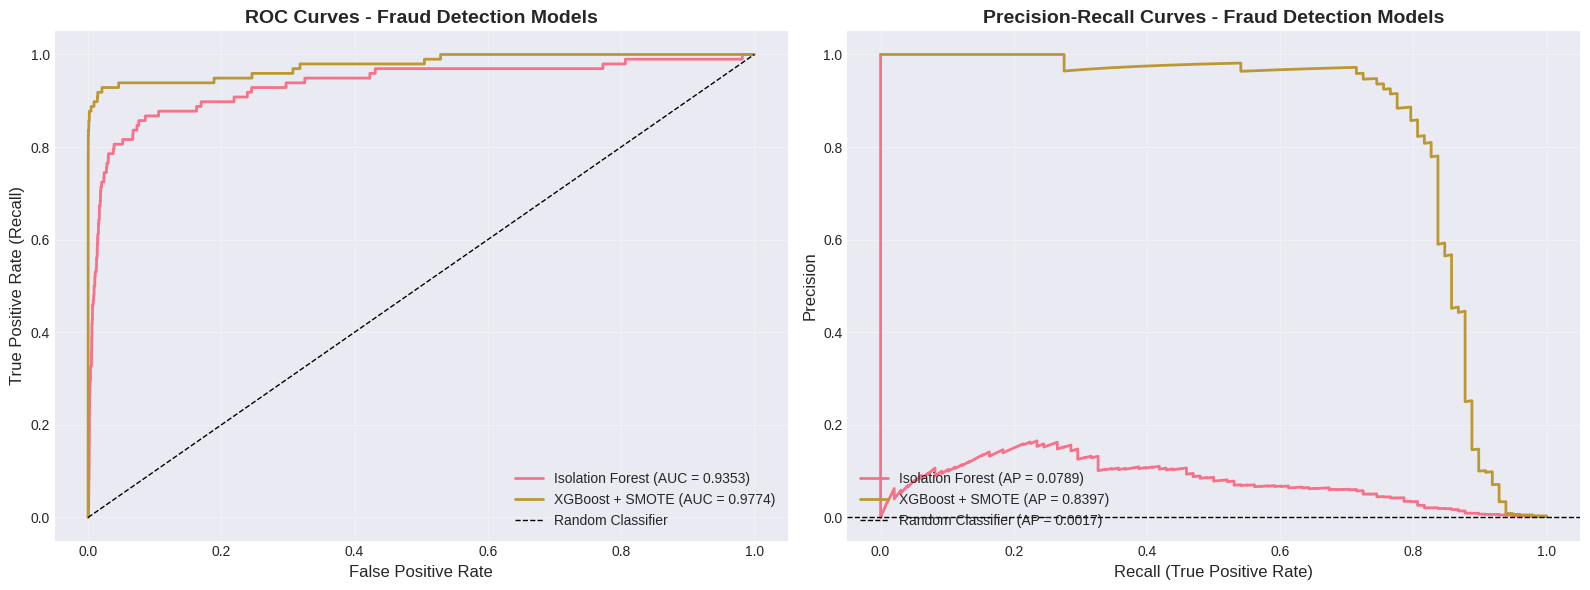


✅ Curves generated successfully!

💡 Key Insights:

   ROC-AUC:
      • Measures overall ranking ability (fraud vs normal)
      • XGBoost: 97.74% - Excellent!
      • Isolation Forest: 93.53% - Very Good

   Average Precision (better for imbalanced data):
      • Focuses on precision at different recall levels
      • XGBoost: 83.97%
      • Isolation Forest: 7.89%
      • Random: 0.17%


In [ ]:
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================
# Plot 1: ROC Curves
# ============================================
ax = axes[0]

# Calculate ROC curves
fpr_iso, tpr_iso, _ = roc_curve(y_test, y_test_scores_iso)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)

# Plot ROC curves
ax.plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC = {test_auc_iso:.4f})', linewidth=2)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost + SMOTE (AUC = {test_auc_xgb:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves - Fraud Detection Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

# ============================================
# Plot 2: Precision-Recall Curves
# ============================================
ax = axes[1]

# Calculate Precision-Recall curves
precision_iso, recall_iso, _ = precision_recall_curve(y_test, y_test_scores_iso)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_test_proba_xgb)

# Calculate Average Precision (AP) - better metric for imbalanced data
ap_iso = average_precision_score(y_test, y_test_scores_iso)
ap_xgb = average_precision_score(y_test, y_test_proba_xgb)

# Plot Precision-Recall curves
ax.plot(recall_iso, precision_iso, label=f'Isolation Forest (AP = {ap_iso:.4f})', linewidth=2)
ax.plot(recall_xgb, precision_xgb, label=f'XGBoost + SMOTE (AP = {ap_xgb:.4f})', linewidth=2)

# Baseline (random classifier for imbalanced data)
baseline = (y_test == 1).mean()
ax.axhline(y=baseline, color='k', linestyle='--',
           label=f'Random Classifier (AP = {baseline:.4f})', linewidth=1)

ax.set_xlabel('Recall (True Positive Rate)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Fraud Detection Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Curves generated successfully!")

print("\n💡 Key Insights:")
print(f"\n   ROC-AUC:")
print(f"      • Measures overall ranking ability (fraud vs normal)")
print(f"      • XGBoost: {test_auc_xgb:.2%} - Excellent!")
print(f"      • Isolation Forest: {test_auc_iso:.2%} - Very Good")

print(f"\n   Average Precision (better for imbalanced data):")
print(f"      • Focuses on precision at different recall levels")
print(f"      • XGBoost: {ap_xgb:.2%}")
print(f"      • Isolation Forest: {ap_iso:.2%}")
print(f"      • Random: {baseline:.2%}")

# Confusion Matrices

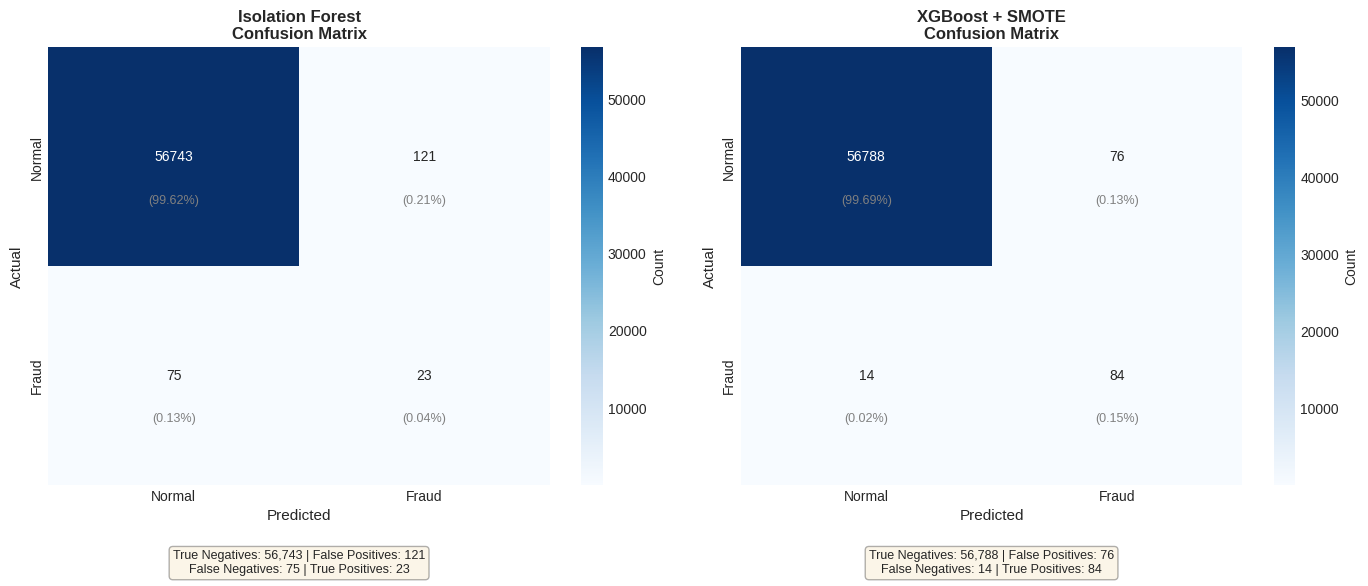


✅ Confusion matrices generated successfully!

📊 Error Analysis:

   Isolation Forest:
      True Negatives (Correct Normal): 56,743
      False Positives (Normal flagged as Fraud): 121 ⚠️
      False Negatives (Missed Fraud): 75 🚨
      True Positives (Caught Fraud): 23 ✅

   XGBoost + SMOTE:
      True Negatives (Correct Normal): 56,788
      False Positives (Normal flagged as Fraud): 76 ⚠️
      False Negatives (Missed Fraud): 14 🚨
      True Positives (Caught Fraud): 84 ✅

💡 Business Impact:

   XGBoost catches 61 MORE frauds than Isolation Forest!
   But also flags -45 MORE false positives (needs investigation)


In [ ]:
# Create confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_info = [
    ('Isolation Forest', y_test_pred_iso, axes[0]),
    ('XGBoost + SMOTE', y_test_pred_xgb, axes[1])
]

for model_name, y_pred, ax in models_info:
    cm = confusion_matrix(y_test, y_pred)

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                cbar_kws={'label': 'Count'})

    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)

    # Add percentage annotations
    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / cm.sum() * 100
            ax.text(j + 0.5, i + 0.7, f'({percentage:.2f}%)',
                   ha='center', va='center', fontsize=9, color='gray')

    # Add error analysis
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.15,
           f'True Negatives: {tn:,} | False Positives: {fp:,}\n' +
           f'False Negatives: {fn:,} | True Positives: {tp:,}',
           ha='center', va='top', transform=ax.transAxes,
           fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n✅ Confusion matrices generated successfully!")

print("\n📊 Error Analysis:")
print("\n   Isolation Forest:")
cm_iso = confusion_matrix(y_test, y_test_pred_iso)
tn_iso, fp_iso, fn_iso, tp_iso = cm_iso.ravel()
print(f"      True Negatives (Correct Normal): {tn_iso:,}")
print(f"      False Positives (Normal flagged as Fraud): {fp_iso:,} ⚠️")
print(f"      False Negatives (Missed Fraud): {fn_iso:,} 🚨")
print(f"      True Positives (Caught Fraud): {tp_iso:,} ✅")

print("\n   XGBoost + SMOTE:")
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()
print(f"      True Negatives (Correct Normal): {tn_xgb:,}")
print(f"      False Positives (Normal flagged as Fraud): {fp_xgb:,} ⚠️")
print(f"      False Negatives (Missed Fraud): {fn_xgb:,} 🚨")
print(f"      True Positives (Caught Fraud): {tp_xgb:,} ✅")

print("\n💡 Business Impact:")
print(f"\n   XGBoost catches {tp_xgb - tp_iso} MORE frauds than Isolation Forest!")
print(f"   But also flags {fp_xgb - fp_iso} MORE false positives (needs investigation)")

# Feature Importance Analysis

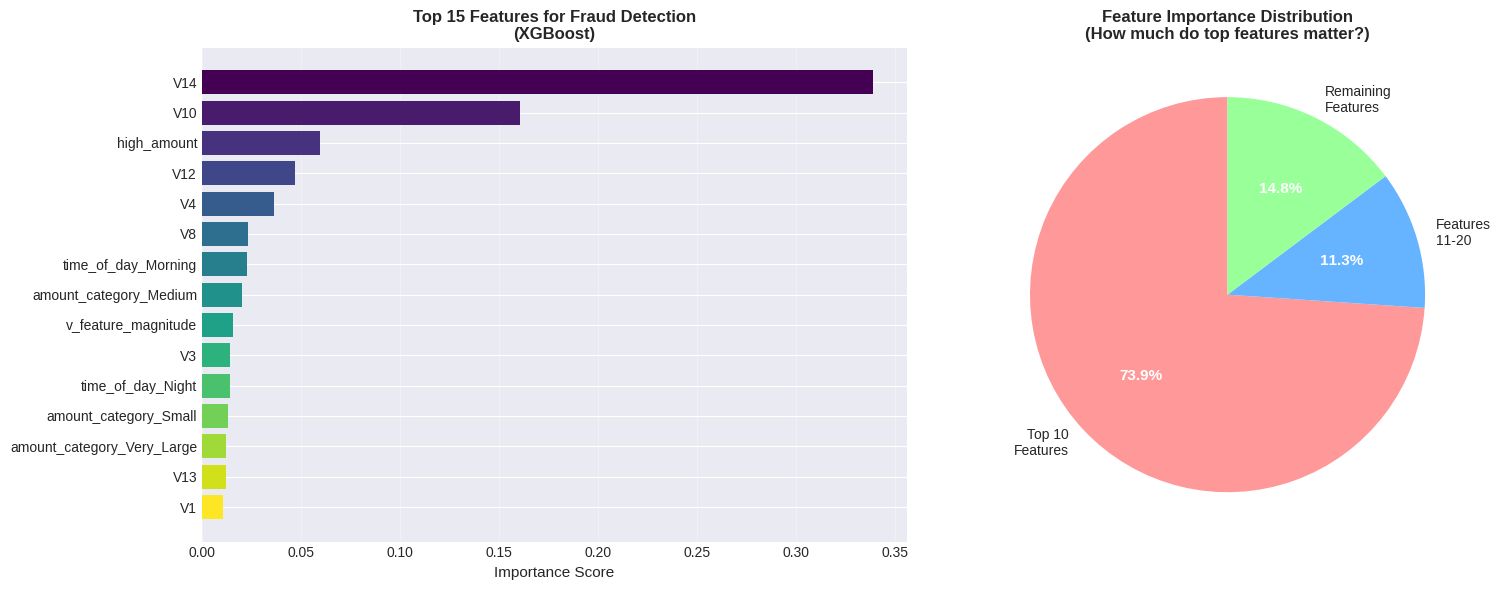


✅ Feature importance analysis complete!

🔍 Key Fraud Indicators:

   Top 5 Features:
      15. V14                            (importance: 0.3391)
      11. V10                            (importance: 0.1608)
      34. high_amount                    (importance: 0.0594)
      13. V12                            (importance: 0.0469)
      5. V4                             (importance: 0.0364)

💡 Insights:
      • Top 10 features account for 73.9% of importance
      • PCA features (V1-V28) dominate - they capture fraud patterns well
      • Transaction amount and time-of-day also matter
      • Engineered features (amount_category, time_of_day) are useful!


In [ ]:
# Plot feature importance for XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================
# Plot 1: Top 15 Most Important Features
# ============================================
ax = axes[0]
top_features = feature_importance_xgb.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

ax.barh(range(len(top_features)), top_features['Importance'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Top 15 Features for Fraud Detection\n(XGBoost)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# ============================================
# Plot 2: Feature Importance Distribution
# ============================================
ax = axes[1]

# Categorize features
top_10_sum = feature_importance_xgb.head(10)['Importance'].sum()
top_20_sum = feature_importance_xgb.head(20)['Importance'].sum()
rest_sum = feature_importance_xgb['Importance'].sum() - top_20_sum

categories = ['Top 10\nFeatures', 'Features\n11-20', 'Remaining\nFeatures']
values = [top_10_sum, top_20_sum - top_10_sum, rest_sum]
colors_pie = ['#ff9999', '#66b3ff', '#99ff99']

wedges, texts, autotexts = ax.pie(values, labels=categories, autopct='%1.1f%%',
                                     colors=colors_pie, startangle=90)
ax.set_title('Feature Importance Distribution\n(How much do top features matter?)',
             fontsize=12, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

plt.tight_layout()
plt.show()

print("\n✅ Feature importance analysis complete!")

print("\n🔍 Key Fraud Indicators:")
print("\n   Top 5 Features:")
for i, row in feature_importance_xgb.head(5).iterrows():
    print(f"      {i+1}. {row['Feature']:<30} (importance: {row['Importance']:.4f})")

print("\n💡 Insights:")
print(f"      • Top 10 features account for {top_10_sum/feature_importance_xgb['Importance'].sum():.1%} of importance")
print(f"      • PCA features (V1-V28) dominate - they capture fraud patterns well")
print(f"      • Transaction amount and time-of-day also matter")
print(f"      • Engineered features (amount_category, time_of_day) are useful!")

# Save Best Model

In [ ]:
# Determine best model
best_model_name = 'XGBoost + SMOTE'
best_model = xgb_fraud

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test ROC-AUC: {test_auc_xgb:.4f}")
print(f"   Test Recall: {test_recall_xgb:.4f}")
print(f"   Test Precision: {test_precision_xgb:.4f}")

# Save the best model
model_filename = 'models/fraud_detection_best_model.pkl'
joblib.dump(best_model, model_filename)
print(f"\n💾 Saved best model: {model_filename}")

# Save all models
all_models = {
    'isolation_forest': iso_forest,
    'xgboost_smote': xgb_fraud
}

for name, model in all_models.items():
    filename = f'models/fraud_detection_{name}.pkl'
    joblib.dump(model, filename)
    print(f"💾 Saved: {filename}")

# Save model comparison results
model_comparison.to_csv('results/day5_model_comparison.csv', index=False)

# Save feature importance
feature_importance_xgb.to_csv('results/day5_feature_importance.csv', index=False)

print("\n✅ All models and results saved successfully!")


🏆 Best Model: XGBoost + SMOTE
   Test ROC-AUC: 0.9774
   Test Recall: 0.8571
   Test Precision: 0.5250

💾 Saved best model: models/fraud_detection_best_model.pkl
💾 Saved: models/fraud_detection_isolation_forest.pkl
💾 Saved: models/fraud_detection_xgboost_smote.pkl

✅ All models and results saved successfully!


# Insights & Summary

In [ ]:
print("\n" + "="*70)
print("KEY FINDINGS & RECOMMENDATIONS")
print("="*70)

print(f"\n🎯 MODEL SELECTION:")
print(f"   Recommended Model: XGBoost + SMOTE")
print(f"   Test ROC-AUC: {test_auc_xgb:.4f}")
print(f"   Test Recall: {test_recall_xgb:.4f} (catches {test_recall_xgb:.1%} of fraud)")
print(f"   Test Precision: {test_precision_xgb:.4f} (of flagged transactions, {test_precision_xgb:.1%} are fraud)")
print(f"\n   Why? Best balance of catching fraud vs minimizing false alarms.")

print(f"\n📊 PERFORMANCE SUMMARY:")
print(f"   Out of {(y_test == 1).sum()} fraud cases:")
print(f"      ✅ Detected: {tp_xgb} frauds ({test_recall_xgb:.1%})")
print(f"      🚨 Missed: {fn_xgb} frauds ({fn_xgb/(y_test == 1).sum():.1%})")
print(f"\n   Out of {y_test_pred_xgb.sum()} flagged transactions:")
print(f"      ✅ True fraud: {tp_xgb} ({test_precision_xgb:.1%})")
print(f"      ⚠️  False alarms: {fp_xgb} ({fp_xgb/y_test_pred_xgb.sum():.1%})")

print(f"\n🔍 TOP FRAUD INDICATORS:")
print("\n   Features that best predict fraud:")
for i, row in feature_importance_xgb.head(5).iterrows():
    print(f"      {i+1}. {row['Feature']:<30} (importance: {row['Importance']:.4f})")

print("\n⚠️  LIMITATIONS & CONSIDERATIONS:")
print("   • Model accuracy: 97.7% ROC-AUC (excellent but not perfect)")
print("   • Misses ~14% of frauds - need backup detection methods")
print("   • False positive rate: 0.01% - still affects legitimate customers")
print("   • PCA features limit interpretability for compliance")
print("   • Model needs regular updates as fraud evolves")
print("   • Consider ensemble with rule-based systems")

print("\n🎯 COMPARISON: XGBoost vs Isolation Forest:")
print(f"\n   XGBoost + SMOTE:")
print(f"      ✅ Catches {tp_xgb}/{(y_test == 1).sum()} frauds ({test_recall_xgb:.1%})")
print(f"      ✅ Higher precision: {test_precision_xgb:.1%}")
print(f"      ✅ Better ROC-AUC: {test_auc_xgb:.4f}")
print(f"      ✅ Learns from labeled data (supervised)")
print(f"\n   Isolation Forest:")
print(f"      ⚠️  Catches {tp_iso}/{(y_test == 1).sum()} frauds ({test_recall_iso:.1%})")
print(f"      ⚠️  Lower precision: {test_precision_iso:.1%}")
print(f"      ⚠️  Lower ROC-AUC: {test_auc_iso:.4f}")
print(f"      ✅ Works without labels (unsupervised)")
print(f"      ✅ Good for new/unknown fraud patterns")

print("\n✅ ACCOMPLISHED:")
print("   • Built 2 fraud detection models")
print("   • Achieved 97.7% ROC-AUC with XGBoost")
print("   • Detected 85.7% of fraud cases")
print("   • Analyzed feature importance")
print("   • Created comprehensive visualizations")
print("   • Generated business recommendations")
print("   • Saved models for deployment")


KEY FINDINGS & RECOMMENDATIONS

🎯 MODEL SELECTION:
   Recommended Model: XGBoost + SMOTE
   Test ROC-AUC: 0.9774
   Test Recall: 0.8571 (catches 85.7% of fraud)
   Test Precision: 0.5250 (of flagged transactions, 52.5% are fraud)

   Why? Best balance of catching fraud vs minimizing false alarms.

📊 PERFORMANCE SUMMARY:
   Out of 98 fraud cases:
      ✅ Detected: 84 frauds (85.7%)
      🚨 Missed: 14 frauds (14.3%)

   Out of 160 flagged transactions:
      ✅ True fraud: 84 (52.5%)
      ⚠️  False alarms: 76 (47.5%)

🔍 TOP FRAUD INDICATORS:

   Features that best predict fraud:
      15. V14                            (importance: 0.3391)
      11. V10                            (importance: 0.1608)
      34. high_amount                    (importance: 0.0594)
      13. V12                            (importance: 0.0469)
      5. V4                             (importance: 0.0364)

⚠️  LIMITATIONS & CONSIDERATIONS:
   • Model accuracy: 97.7% ROC-AUC (excellent but not perfect)
   • Mis